# Oráculo del simulador de I/Q (Zrnić, 1975)

Paso 1 del método del roadmap (`docs/algorithms/roadmap.md` §"Método de
estudio: oráculo en Python, luego Rust"): implementación independiente en
Python/numpy de la formulación de Zrnić (1975) y de Doviak & Zrnić (1993, caps.
4 y 6), para contrastar la implementación Rust de `crates/simulator` sin
compartir camino con ella. Ver `docs/algorithms/simulador-iq.md`.

Este notebook no importa nada de `lamula-simulator`: cada fórmula se escribe
desde el paper. La verdad-terreno no es "lo que hace el código Rust" sino el
modelo físico cerrado de la sección 1, así que un error conceptual compartido
entre las dos implementaciones (p.ej. una mala interpretación de la fórmula) sí
se detecta aquí, al contrario que contrastar el simulador contra sí mismo.

In [1]:
import numpy as np
from numpy.fft import fft
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(20260831)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

## 1. Modelo analítico continuo (verdad-terreno)

Doviak & Zrnić (1993), cap. 6: el eco de un volumen lleno de dispersores
independientes es un proceso gaussiano complejo de media cero cuya densidad
espectral de potencia es gaussiana en velocidad, centrada en la velocidad
radial media `v̄` con desviación estándar (ancho espectral) `σv`. Pasando a la
variable de Doppler `f = 2v/λ` y tomando la transformada de Fourier inversa de
una gaussiana (que es otra gaussiana), la autocovarianza en tiempo continuo
tiene forma cerrada:

`R(τ) = S · exp(j·4π·v̄·τ/λ) · exp(-8π²·σv²·τ²/λ²)`

Esta fórmula **no depende de ninguna discretización FFT ni de ningún código**:
es la referencia contra la que se contrasta todo lo que sigue.

In [2]:
def analytic_acf_continuous(power_s, mean_v, sigma_v, wavelength_m, tau):
    """R(tau) cerrada de Doviak & Zrnic (1993) cap. 6 para un espectro
    Doppler gaussiano. Independiente de cualquier discretizacion FFT."""
    phase = np.exp(1j * 4 * np.pi * mean_v * tau / wavelength_m)
    decay = np.exp(-8 * np.pi**2 * sigma_v**2 * tau**2 / wavelength_m**2)
    return power_s * phase * decay

## 2. Discretización: espectro Doppler gaussiano en la rejilla FFT

Para generar una serie temporal hace falta discretizar `S(f)` en `M` bins
separados por `1/(M·PRT)`, con las réplicas envolventes que exige la
periodicidad del intervalo de Nyquist (ancho `2·v_a`, con
`v_a = λ/(4·PRT)`). Implementado desde cero en numpy, no desde
`crates/simulator/src/spectrum.rs`.

In [3]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    """Densidad espectral discreta S[k] en el orden nativo de bin de la FFT
    (bin 0 = continua, crecientes hasta Nyquist, luego negativos envueltos),
    normalizada para que sum(S) == power_s."""
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)          # orden nativo de bin, igual que rustfft
    v_k = f_k * wavelength_m / 2.0

    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)

    return acc * power_s / acc.sum()


def discrete_acf(spectrum, prt_s, lag):
    """Autocovarianza implicada por el espectro discreto (suma directa),
    para separar el error de discretizacion/aliasing del error de muestreo
    estadistico frente al modelo continuo de la seccion 1."""
    m = spectrum.size
    k = np.arange(m)
    phase = np.exp(-1j * 2 * np.pi * k * lag / m)
    return np.sum(spectrum * phase)

## 3. Generación de la serie temporal: conformado espectral + IFFT

Método de Zrnić (1975): multiplicar la raíz del espectro objetivo por ruido
blanco gaussiano complejo circularmente simétrico, aplicar la IFFT *no
normalizada* (`y[n] = Σ_k X[k]·e^{j2πkn/M}`, sin el `1/M` que aplica por
defecto `numpy.fft.ifft`) y sumar ruido térmico. La convención no normalizada
es la que hace que `E[|y[n]|²] = Σ_k S[k] = power_s` sin factor de escala
adicional, porque cada bin `shaped[k] = w[k]·√S[k]` tiene
`E[|shaped[k]|²] = S[k]` y los bins son independientes. Se comprueba
empíricamente en la sección 4, no se asume.

In [4]:
def complex_gaussian(rng, variance, size=None):
    """CN(0, variance): partes real e imaginaria independientes N(0, variance/2)."""
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m  # IFFT no normalizada, ver nota de arriba
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y

## 4. Validación: autocovarianza muestral vs modelo cerrado

Parámetros iguales a `crates/simulator/tests/statistical.rs::test_params` para
que la comparación cualitativa entre el oráculo y el test Rust sea directa
(no son la misma ejecución: cada uno trae su propio generador de números
aleatorios). `N = 20000` realizaciones, retardos 0 a 3 PRT.

In [5]:
POWER_S = 1.0
MEAN_V = 5.0
SIGMA_V = 1.5
WAVELENGTH_M = 0.10
PRT_S = 1.0e-3
M = 64
N = 20_000

spectrum = gaussian_doppler_spectrum(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M)

cells_iq = np.array([
    generate_cell(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M, 0.0, rng)
    for _ in range(N)
])  # (N, M)

checks = []
print(f"{'lag':>3} {'|R sample|':>12} {'stderr':>10} {'|R discreto|':>14} {'|R continuo|':>14} {'diff/stderr':>12}")
for lag in range(4):
    samples = cells_iq[:, 0] * np.conj(cells_iq[:, lag])
    mean = samples.mean()
    variance = samples.var(ddof=1)
    stderr = np.sqrt(variance / N)

    r_discrete = discrete_acf(spectrum, PRT_S, lag)
    r_continuous = analytic_acf_continuous(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, lag * PRT_S)

    diff_sigma = abs(mean - r_discrete) / stderr
    print(f"{lag:>3} {abs(mean):>12.4f} {stderr:>10.2e} {abs(r_discrete):>14.4f} {abs(r_continuous):>14.4f} {diff_sigma:>12.2f}")

    checks.append(("autocovarianza lag=%d dentro de 5*stderr del espectro discreto" % lag, diff_sigma < 5.0))
    checks.append(("autocovarianza lag=%d dentro de 1%% del modelo continuo" % lag,
                    abs(abs(r_discrete) - abs(r_continuous)) / abs(r_continuous) < 0.01))

lag   |R sample|     stderr   |R discreto|   |R continuo|  diff/stderr
  0       0.9864   7.11e-03         1.0000         1.0000         1.91
  1       0.9686   7.09e-03         0.9824         0.9824         1.95
  2       0.9179   7.07e-03         0.9314         0.9314         1.92
  3       0.8396   7.04e-03         0.8522         0.8522         1.81


El espectro discreto y el modelo continuo deben coincidir salvo un
resto de aliasing despreciable (`σv=1.5 m/s` frente a `v_a≈{:.1f} m/s`, tres
réplicas envolventes a cada lado): eso es lo que confirma la segunda columna de
comprobación. La primera columna confirma que el generador (sección 3)
reproduce el espectro que se le pidió, dentro del error estadístico de `N`
realizaciones.

v_a = 25.00 m/s


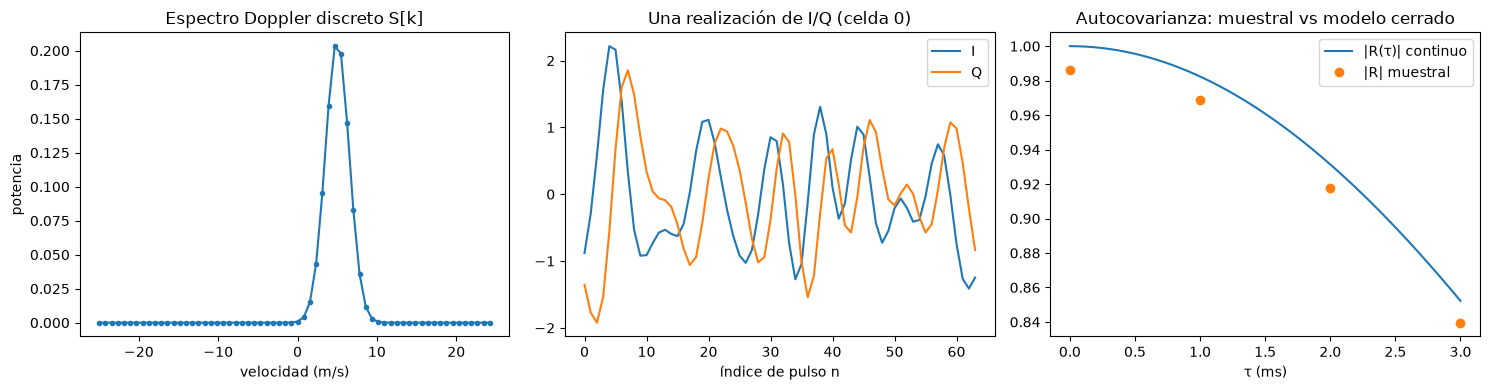

In [6]:
print(f"v_a = {WAVELENGTH_M / (4.0 * PRT_S):.2f} m/s")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

v_grid = np.fft.fftshift(np.fft.fftfreq(M, d=PRT_S)) * WAVELENGTH_M / 2.0
axes[0].plot(v_grid, np.fft.fftshift(spectrum), marker="o", ms=3)
axes[0].set_title("Espectro Doppler discreto S[k]")
axes[0].set_xlabel("velocidad (m/s)")
axes[0].set_ylabel("potencia")

n_idx = np.arange(M)
axes[1].plot(n_idx, cells_iq[0].real, label="I")
axes[1].plot(n_idx, cells_iq[0].imag, label="Q")
axes[1].set_title("Una realización de I/Q (celda 0)")
axes[1].set_xlabel("índice de pulso n")
axes[1].legend()

tau_grid = np.linspace(0, 3 * PRT_S, 200)
axes[2].plot(tau_grid * 1e3, np.abs(analytic_acf_continuous(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, tau_grid)),
             label="|R(τ)| continuo")
lags = np.arange(4)
sample_acf = [np.abs((cells_iq[:, 0] * np.conj(cells_iq[:, lag])).mean()) for lag in lags]
axes[2].plot(lags * PRT_S * 1e3, sample_acf, "o", label="|R| muestral")
axes[2].set_title("Autocovarianza: muestral vs modelo cerrado")
axes[2].set_xlabel("τ (ms)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Distribución marginal: potencia exponencial, fase uniforme

La potencia instantánea de un proceso gaussiano complejo es marginalmente
exponencial (amplitud Rayleigh) y la fase uniforme en `[-π, π)`,
independientemente de la correlación temporal — basta agrupar las muestras de
muchas realizaciones cortas. Contraste con test de Kolmogorov-Smirnov contra
las distribuciones teóricas, no con un chi-cuadrado de bins arbitrarios.

KS potencia vs Exponential(media=1.0): estadístico=0.0033, p=0.4844
KS fase vs Uniform(-π,π):                    estadístico=0.0025, p=0.8017


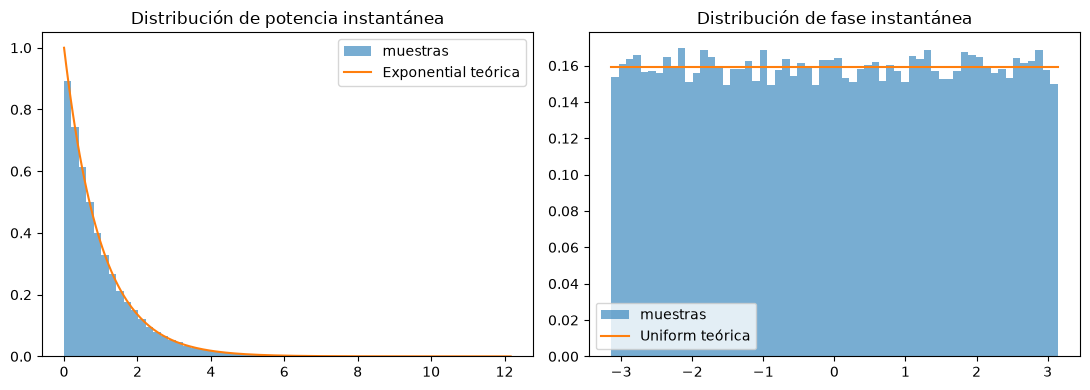

In [7]:
M_SHORT = 16
REALIZATIONS = 4000

short_cells = np.array([
    generate_cell(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M_SHORT, 0.0, rng)
    for _ in range(REALIZATIONS)
])

powers = np.abs(short_cells).ravel() ** 2
phases = np.angle(short_cells).ravel()

ks_power = stats.kstest(powers, stats.expon(scale=POWER_S).cdf)
ks_phase = stats.kstest(phases, stats.uniform(loc=-np.pi, scale=2 * np.pi).cdf)

print(f"KS potencia vs Exponential(media={POWER_S}): estadístico={ks_power.statistic:.4f}, p={ks_power.pvalue:.4f}")
print(f"KS fase vs Uniform(-π,π):                    estadístico={ks_phase.statistic:.4f}, p={ks_phase.pvalue:.4f}")

checks.append(("potencia instantánea es exponencial (KS p>1e-3)", ks_power.pvalue > 1e-3))
checks.append(("fase instantánea es uniforme (KS p>1e-3)", ks_phase.pvalue > 1e-3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x_p = np.linspace(0, powers.max(), 200)
axes[0].hist(powers, bins=60, density=True, alpha=0.6, label="muestras")
axes[0].plot(x_p, stats.expon(scale=POWER_S).pdf(x_p), label="Exponential teórica")
axes[0].set_title("Distribución de potencia instantánea")
axes[0].legend()

x_ph = np.linspace(-np.pi, np.pi, 200)
axes[1].hist(phases, bins=60, density=True, alpha=0.6, label="muestras")
axes[1].plot(x_ph, stats.uniform(loc=-np.pi, scale=2 * np.pi).pdf(x_ph), label="Uniform teórica")
axes[1].set_title("Distribución de fase instantánea")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Doble polarización: recuperación de ZDR, ρHV, ΦDP

Modo simultáneo (STAR): H y V comparten la misma forma Doppler y sólo cambia
la potencia total de V vía ZDR; la correlación cruzada `ρ = ρHV·e^{jΦDP}` se
impone por Cholesky de `[[1, ρ*], [ρ, 1]]` sobre el ruido blanco de cada bin
*antes* del conformado espectral, para que la correlación exista muestra a
muestra y no sólo en potencia agregada. Escrito desde `docs/algorithms/
simulador-iq.md` §"Variabilidad polarimétrica", no desde
`generate_dual_pol_cell` de Rust.

ZDR:   pedido=2.00 dB   estimado=2.02 dB
ρHV:   pedido=0.970      estimado=0.970
ΦDP:   pedido=30.0°  estimado=30.1°
cruzada: |diff|/stderr = 0.16


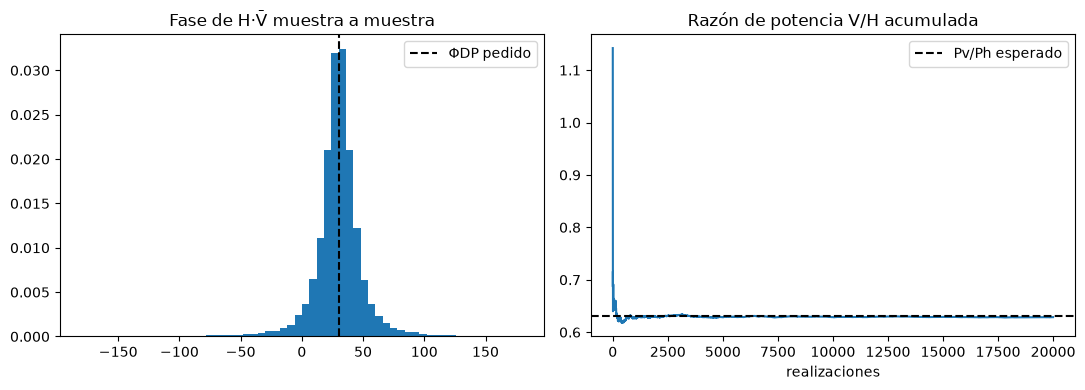

In [8]:
def generate_dual_pol_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m,
                            zdr_db, rho_hv, phidp_deg, rng, wrap=3):
    assert 0.0 <= rho_hv <= 1.0

    power_v = power_s / 10.0 ** (zdr_db / 10.0)
    spectrum_h = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    spectrum_v = gaussian_doppler_spectrum(power_v, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)

    rho = rho_hv * np.exp(1j * np.radians(phidp_deg))
    l21 = np.conj(rho)
    l22 = np.sqrt(1.0 - rho_hv ** 2)

    w1 = complex_gaussian(rng, 1.0, size=m)
    w2 = complex_gaussian(rng, 1.0, size=m)
    wh = w1
    wv = l21 * w1 + l22 * w2

    shaped_h = wh * np.sqrt(spectrum_h)
    shaped_v = wv * np.sqrt(spectrum_v)

    y_h = np.fft.ifft(shaped_h) * m
    y_v = np.fft.ifft(shaped_v) * m
    return y_h, y_v


ZDR_DB = 2.0
RHO_HV = 0.97
PHIDP_DEG = 30.0
N_DUAL = 20_000

h0 = np.empty(N_DUAL, dtype=complex)
v0 = np.empty(N_DUAL, dtype=complex)
for i in range(N_DUAL):
    h, v = generate_dual_pol_cell(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, 16,
                                   ZDR_DB, RHO_HV, PHIDP_DEG, rng)
    h0[i] = h[0]
    v0[i] = v[0]

power_h_hat = np.mean(np.abs(h0) ** 2)
power_v_hat = np.mean(np.abs(v0) ** 2)
zdr_hat = 10.0 * np.log10(power_h_hat / power_v_hat)

cross = h0 * np.conj(v0)
cross_mean = cross.mean()
cross_stderr = np.sqrt(cross.var(ddof=1) / N_DUAL)
norm = np.sqrt(power_h_hat * power_v_hat)
rho_hv_hat = np.abs(cross_mean) / norm
phidp_hat = np.degrees(np.angle(cross_mean))

expected_cross = RHO_HV * np.exp(1j * np.radians(PHIDP_DEG)) * norm
diff_sigma = np.abs(cross_mean - expected_cross) / cross_stderr

print(f"ZDR:   pedido={ZDR_DB:.2f} dB   estimado={zdr_hat:.2f} dB")
print(f"ρHV:   pedido={RHO_HV:.3f}      estimado={rho_hv_hat:.3f}")
print(f"ΦDP:   pedido={PHIDP_DEG:.1f}°  estimado={phidp_hat:.1f}°")
print(f"cruzada: |diff|/stderr = {diff_sigma:.2f}")

checks.append(("ZDR estimado dentro de 2% del pedido", abs(zdr_hat - ZDR_DB) / ZDR_DB < 0.02))
checks.append(("correlación cruzada (ρHV, ΦDP) dentro de 5*stderr", diff_sigma < 5.0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.degrees(np.angle(cross)), bins=60, density=True)
ax[0].axvline(PHIDP_DEG, color="k", ls="--", label="ΦDP pedido")
ax[0].set_title("Fase de H·V̄ muestra a muestra")
ax[0].legend()

power_ratio_running = np.cumsum(np.abs(v0) ** 2) / np.cumsum(np.abs(h0) ** 2)
ax[1].plot(power_ratio_running)
ax[1].axhline(10.0 ** (-ZDR_DB / 10.0), color="k", ls="--", label="Pv/Ph esperado")
ax[1].set_title("Razón de potencia V/H acumulada")
ax[1].set_xlabel("realizaciones")
ax[1].legend()

plt.tight_layout()
plt.show()

## 7. Resumen de aceptación

In [9]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo del simulador de I/Q no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] autocovarianza lag=0 dentro de 5*stderr del espectro discreto
[OK] autocovarianza lag=0 dentro de 1% del modelo continuo
[OK] autocovarianza lag=1 dentro de 5*stderr del espectro discreto
[OK] autocovarianza lag=1 dentro de 1% del modelo continuo
[OK] autocovarianza lag=2 dentro de 5*stderr del espectro discreto
[OK] autocovarianza lag=2 dentro de 1% del modelo continuo
[OK] autocovarianza lag=3 dentro de 5*stderr del espectro discreto
[OK] autocovarianza lag=3 dentro de 1% del modelo continuo
[OK] potencia instantánea es exponencial (KS p>1e-3)
[OK] fase instantánea es uniforme (KS p>1e-3)
[OK] ZDR estimado dentro de 2% del pedido
[OK] correlación cruzada (ρHV, ΦDP) dentro de 5*stderr

Todas las comprobaciones dentro de tolerancia.
